In [2]:
#installing and importing libraries
!pip install yfinance --quiet

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
#loading dataset
ticker = "AAPL"

data = yf.Ticker(ticker)
df = data.history(period="15y")

df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2011-04-21 00:00:00-04:00,10.636865,10.640761,10.442705,10.508024,753810400,0.0,0.0
2011-04-25 00:00:00-04:00,10.497240,10.599414,10.496041,10.577241,266546000,0.0,0.0
2011-04-26 00:00:00-04:00,10.595520,10.636569,10.467578,10.499639,338800000,0.0,0.0
2011-04-27 00:00:00-04:00,10.554173,10.557470,10.400164,10.491550,356213200,0.0,0.0
2011-04-28 00:00:00-04:00,10.372892,10.479559,10.352816,10.389671,360959200,0.0,0.0


In [7]:
# preparing dataset
df = df[['Open', 'High', 'Low', 'Volume', 'Close']]

# Create target (next day close)
df['Target'] = df['Close'].shift(-1)

df = df.dropna()

print("\nData after preprocessing:")
print(df.head())


Data after preprocessing:
                                Open       High        Low     Volume  \
Date                                                                    
2011-04-21 00:00:00-04:00  10.636865  10.640761  10.442705  753810400   
2011-04-25 00:00:00-04:00  10.497240  10.599414  10.496041  266546000   
2011-04-26 00:00:00-04:00  10.595520  10.636569  10.467578  338800000   
2011-04-27 00:00:00-04:00  10.554173  10.557470  10.400164  356213200   
2011-04-28 00:00:00-04:00  10.372892  10.479559  10.352816  360959200   

                               Close     Target  
Date                                             
2011-04-21 00:00:00-04:00  10.508024  10.577241  
2011-04-25 00:00:00-04:00  10.577241  10.499639  
2011-04-26 00:00:00-04:00  10.499639  10.491550  
2011-04-27 00:00:00-04:00  10.491550  10.389671  
2011-04-28 00:00:00-04:00  10.389671  10.490946  


In [8]:
#DEFINE FEATURES & LABEL

# Features (input variables)
X = df[['Open', 'High', 'Low', 'Volume']]

# Target (output variable)
y = df['Target']

In [9]:
# Use 80% data for training and 20% for testing
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [10]:
# Create model
model = LinearRegression()

# Train model on training data
model.fit(X_train, y_train)

LinearRegression()

In [11]:
# Predict on test data
y_pred = model.predict(X_test)

# Show first 5 predictions
print("\nSample Predictions:")
print(y_pred[:5])


Sample Predictions:
[162.34040086 164.73863842 165.48097797 165.03868783 163.67210409]


In [12]:
# Calculate error metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Evaluation:")
print("MAE:", mae)
print("RMSE:", rmse)



Model Evaluation:
MAE: 2.54972220950618
RMSE: 3.677524628394157


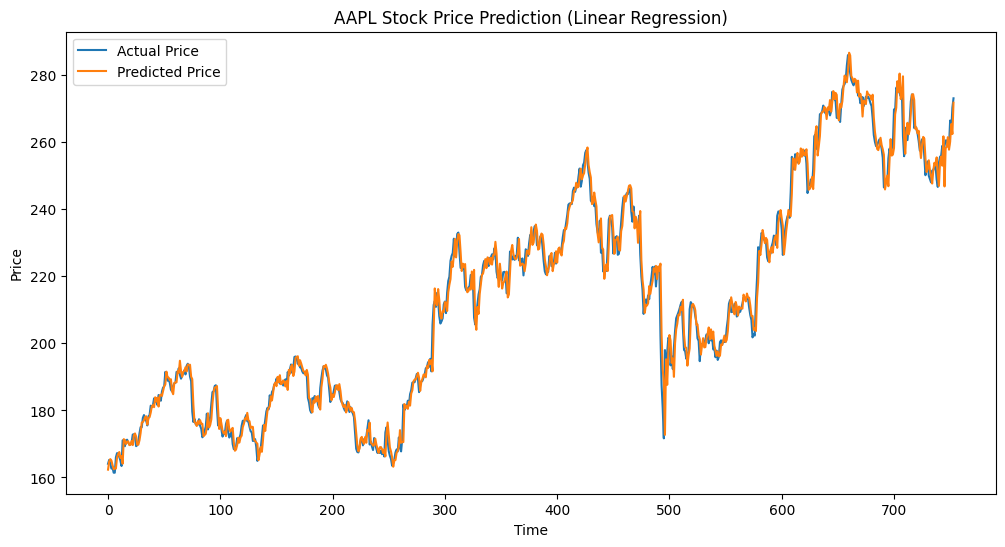

In [13]:
plt.figure(figsize=(12,6))

# Plot actual prices
plt.plot(y_test.values, label="Actual Price")

# Plot predicted prices
plt.plot(y_pred, label="Predicted Price")

# Add title and labels
plt.title(f"{ticker} Stock Price Prediction (Linear Regression)")
plt.xlabel("Time")
plt.ylabel("Price")

# Show legend
plt.legend()

# Display plot
plt.show()


In [14]:
# Example: new day's values (Open, High, Low, Volume)
new_data = pd.DataFrame([[170, 175, 168, 30000000]],
                        columns=['Open', 'High', 'Low', 'Volume'])

# Predict next day's closing price
prediction = model.predict(new_data)

print("\nPredicted Next Day Close Price:", prediction)


Predicted Next Day Close Price: [172.62170442]


In [15]:
import joblib
joblib.dump(model, "stock_price_model.pkl")

['stock_price_model.pkl']